In [1]:
# ============================================
# nondim.py
# Non-dimensionalisation framework for OPV PINN
# Swap constants at the bottom to go from
# normalised → physical → any real material
# ============================================
import numpy as np
import torch

# ============================================
# PHYSICAL CONSTANTS (never change these)
# ============================================
q_SI   = 1.602e-19    # C
k_B    = 8.617e-5     # eV/K
eps_0  = 8.854e-12    # F/m

# ============================================
# MATERIAL PARAMETER SETS
# Easy to swap — just change which one you use
# ============================================

class NormalisedParams:
    """
    Current working parameters — dimensionless.
    All equations work exactly as written.
    Reference: everything = 1.
    """
    name   = "Normalised (dimensionless)"

    # Reference scales — trivial in normalised units
    L0     = 1.0        # length scale
    V0     = 1.0        # voltage scale
    n0     = 1.0        # carrier density scale
    T      = 300        # temperature (K)

    # Dimensionless parameters — these go into compute_all
    q      = 1.0
    Vt     = 0.025
    eps    = 1.0
    mu_n   = 1.0
    mu_p   = 1.0
    mu_X   = 1.0
    k_rec  = 0.1
    k_diss = 5.0
    G      = 0.1

    # Debye ratio — appears in Poisson equation
    # In normalised: eps * d²phi/dx² = q*(n-p) with this = 1
    debye_ratio = 1.0


class P3HT_PCBM_Params:
    """
    P3HT:PCBM — most studied OPV material pair.
    Physical SI units, then non-dimensionalised.
    Reference: Blom et al., Brabec et al.
    """
    name = "P3HT:PCBM (physical)"

    # Device geometry
    L_phys  = 100e-9      # m   device thickness
    T       = 300         # K   temperature

    # Reference scales
    L0      = L_phys                         # 100 nm
    V0      = k_B * T                        # 0.026 V (thermal voltage)
    mu_n_SI = 1e-7                           # m²/Vs (1e-3 cm²/Vs)
    n0      = 1e22                           # m⁻³  reference density
    t0      = L0**2 / (mu_n_SI * V0)        # diffusion time

    # Physical parameters
    q_phys     = q_SI
    eps_r      = 3.5
    eps_phys   = eps_r * eps_0

    mu_n_phys  = 1e-7        # m²/Vs  electron mobility
    mu_p_phys  = 1e-8        # m²/Vs  hole mobility (10x lower)
    mu_X_phys  = 1e-8        # m²/Vs  exciton mobility
    k_rec_phys = 1e-18       # m³/s   bimolecular recombination
    k_diss_phys= 1e8         # s⁻¹   dissociation rate
    G_phys     = 1e27        # m⁻³s⁻¹ generation rate
    L_D        = 10e-9       # m      exciton diffusion length

    # ----------------------------------------
    # NON-DIMENSIONALISED PARAMETERS
    # These go into compute_all — all O(1)
    # ----------------------------------------
    q      = 1.0                    # always 1 after non-dim

    Vt     = k_B * T / V0          # = 1.0 by construction

    eps    = (eps_phys * V0) / (q_SI * n0 * L0**2)
    # Debye ratio: how strongly charge curves phi
    # Typical value for OPV: 0.1 to 10

    mu_n   = 1.0                    # reference mobility
    mu_p   = mu_p_phys / mu_n_phys # = 0.1 (ratio matters)
    mu_X   = mu_X_phys / mu_n_phys # = 0.1

    k_rec  = k_rec_phys * n0 * t0  # dimensionless recombination
    k_diss = k_diss_phys * t0      # dimensionless dissociation
    G      = G_phys * t0 / n0      # dimensionless generation

    # Debye ratio — prefactor in Poisson equation
    debye_ratio = (q_SI * n0 * L0**2) / (eps_phys * V0)

    @classmethod
    def print_summary(cls):
        print(f"\n{'='*50}")
        print(f"Material: {cls.name}")
        print(f"{'='*50}")
        print(f"  L0     = {cls.L0*1e9:.1f} nm")
        print(f"  V0     = {cls.V0:.4f} V")
        print(f"  n0     = {cls.n0:.2e} m⁻³")
        print(f"  t0     = {cls.t0:.2e} s")
        print(f"\n  Dimensionless parameters:")
        print(f"  Vt     = {cls.Vt:.4f}")
        print(f"  eps    = {cls.eps:.4f}  (Debye ratio = {cls.debye_ratio:.2f})")
        print(f"  mu_n   = {cls.mu_n:.4f}")
        print(f"  mu_p   = {cls.mu_p:.4f}")
        print(f"  mu_X   = {cls.mu_X:.4f}")
        print(f"  k_rec  = {cls.k_rec:.4f}")
        print(f"  k_diss = {cls.k_diss:.4f}")
        print(f"  G      = {cls.G:.6f}")
        print(f"{'='*50}")


class CustomParams:
    """
    Placeholder for real material parameters when they arrive.
    Fill in the _phys values — dimensionless ones compute automatically.
    """
    name = "Custom (fill in when parameters arrive)"

    # ---- FILL THESE IN WHEN YOU GET REAL PARAMETERS ----
    L_phys   = None    # m    device thickness
    T        = 300     # K    temperature
    eps_r    = None    # -    relative permittivity
    mu_n_phys= None    # m²/Vs
    mu_p_phys= None    # m²/Vs
    mu_X_phys= None    # m²/Vs
    k_rec_phys=None    # m³/s
    k_diss_phys=None   # s⁻¹
    G_phys   = None    # m⁻³s⁻¹
    n0       = None    # m⁻³  reference density (choose ~ intrinsic density)
    # ---- END FILL IN ----

    @classmethod
    def compute_dimensionless(cls):
        """Call this after filling in _phys values."""
        assert cls.L_phys is not None, "Fill in L_phys"
        assert cls.mu_n_phys is not None, "Fill in mu_n_phys"

        cls.L0  = cls.L_phys
        cls.V0  = k_B * cls.T
        cls.t0  = cls.L0**2 / (cls.mu_n_phys * cls.V0)

        cls.q      = 1.0
        cls.Vt     = 1.0
        cls.eps    = (cls.eps_r * eps_0 * cls.V0) / (q_SI * cls.n0 * cls.L0**2)
        cls.mu_n   = 1.0
        cls.mu_p   = cls.mu_p_phys / cls.mu_n_phys
        cls.mu_X   = cls.mu_X_phys / cls.mu_n_phys
        cls.k_rec  = cls.k_rec_phys  * cls.n0 * cls.t0
        cls.k_diss = cls.k_diss_phys * cls.t0
        cls.G      = cls.G_phys * cls.t0 / cls.n0
        cls.debye_ratio = (q_SI * cls.n0 * cls.L0**2) / (cls.eps_r * eps_0 * cls.V0)

        print("Dimensionless parameters computed:")
        print(f"  Vt={cls.Vt:.4f} eps={cls.eps:.4f} "
              f"mu_p={cls.mu_p:.4f} k_rec={cls.k_rec:.4f} "
              f"k_diss={cls.k_diss:.4f} G={cls.G:.6f}")
        print(f"  Debye ratio = {cls.debye_ratio:.2f}")

        # Sanity checks
        _sanity_check(cls)


# ============================================
# SANITY CHECKS
# Run these whenever you load new parameters
# ============================================
def _sanity_check(params):
    """
    Check all dimensionless parameters are O(1).
    Warns if any are outside [1e-3, 1e3] — will cause training issues.
    """
    checks = {
        'Vt':     params.Vt,
        'eps':    params.eps,
        'mu_p':   params.mu_p,
        'mu_X':   params.mu_X,
        'k_rec':  params.k_rec,
        'k_diss': params.k_diss,
        'G':      params.G,
    }

    print("\nSanity check — all should be in [1e-3, 1e3]:")
    all_ok = True
    for name, val in checks.items():
        in_range = 1e-3 <= abs(val) <= 1e3
        status   = "✅" if in_range else "⚠️  OUT OF RANGE"
        print(f"  {name:<10} = {val:.4e}  {status}")
        if not in_range:
            all_ok = False

    if not all_ok:
        print("\n  ⚠️  Some parameters out of range.")
        print("  Consider adjusting n0 or L0 reference scales.")
    else:
        print("\n  ✅ All parameters in safe range for training.")


# ============================================
# ACTIVE PARAMETER SET — change this one line
# ============================================
# P = NormalisedParams()      # current working setup
# P = P3HT_PCBM_Params()     # real P3HT:PCBM
# P = CustomParams()          # your real parameters (fill in first)

P = NormalisedParams()       # default — safe to run now

# ============================================
# USAGE IN PINN
# Replace hardcoded constants with P.xxx
# ============================================
# BEFORE:
#   R = k_rec * n * p
#   L_poisson = mean((lap_phi - q*(n-p))**2)
#
# AFTER:
#   R = P.k_rec * n * p
#   L_poisson = mean((P.debye_ratio * lap_phi - P.q*(n-p))**2)
#                     ↑ only Poisson changes — debye_ratio appears here


# ============================================
# TEST — run this cell to verify
# ============================================
if __name__ == "__main__":

    print("=== Testing NormalisedParams ===")
    P_norm = NormalisedParams()
    _sanity_check(P_norm)

    print("\n=== Testing P3HT_PCBM_Params ===")
    P_phys = P3HT_PCBM_Params()
    P_phys.print_summary()
    _sanity_check(P_phys)

    print("\n=== Key difference in Poisson equation ===")
    print(f"  Normalised: ∇²φ = 1.0 * (n-p)")
    print(f"  P3HT:PCBM:  ∇²φ = {P_phys.debye_ratio:.2f} * (n-p)")
    print(f"\n  Debye ratio {P_phys.debye_ratio:.2f} means")
    print(f"  charge has {P_phys.debye_ratio:.1f}x stronger effect on field")
    print(f"  than our normalised model assumed.")

=== Testing NormalisedParams ===

Sanity check — all should be in [1e-3, 1e3]:
  Vt         = 2.5000e-02  ✅
  eps        = 1.0000e+00  ✅
  mu_p       = 1.0000e+00  ✅
  mu_X       = 1.0000e+00  ✅
  k_rec      = 1.0000e-01  ✅
  k_diss     = 5.0000e+00  ✅
  G          = 1.0000e-01  ✅

  ✅ All parameters in safe range for training.

=== Testing P3HT_PCBM_Params ===

Material: P3HT:PCBM (physical)
  L0     = 100.0 nm
  V0     = 0.0259 V
  n0     = 1.00e+22 m⁻³
  t0     = 3.87e-06 s

  Dimensionless parameters:
  Vt     = 1.0000
  eps    = 0.0500  (Debye ratio = 20.00)
  mu_n   = 1.0000
  mu_p   = 0.1000
  mu_X   = 0.1000
  k_rec  = 0.0387
  k_diss = 386.8322
  G      = 0.386832

Sanity check — all should be in [1e-3, 1e3]:
  Vt         = 1.0000e+00  ✅
  eps        = 5.0006e-02  ✅
  mu_p       = 1.0000e-01  ✅
  mu_X       = 1.0000e-01  ✅
  k_rec      = 3.8683e-02  ✅
  k_diss     = 3.8683e+02  ✅
  G          = 3.8683e-01  ✅

  ✅ All parameters in safe range for training.

=== Key difference i

In [ ]:
# ============================================
# UPDATED COMPUTE ALL — uses parameter object P
# Drop-in replacement — same structure as before
# ============================================
def compute_all(coords, M_flat, model, P):
    """
    P is any parameter object:
      NormalisedParams, P3HT_PCBM_Params, or CustomParams
    Switch material by passing a different P.
    """
    phi, n, p, X = model(coords, M_flat)

    grad_phi = grad(phi, coords)
    grad_n   = grad(n,   coords)
    grad_p   = grad(p,   coords)
    grad_X   = grad(X,   coords)
    lap_phi  = laplacian(phi, coords)
    lap_X    = laplacian(X,   coords)

    Jn_x = -P.q*n*P.mu_n*grad_phi[:,0:1] + P.q*P.Vt*P.mu_n*grad_n[:,0:1]
    Jn_y = -P.q*n*P.mu_n*grad_phi[:,1:2] + P.q*P.Vt*P.mu_n*grad_n[:,1:2]
    Jp_x = -P.q*p*P.mu_p*grad_phi[:,0:1] - P.q*P.Vt*P.mu_p*grad_p[:,0:1]
    Jp_y = -P.q*p*P.mu_p*grad_phi[:,1:2] - P.q*P.Vt*P.mu_p*grad_p[:,1:2]

    div_Jn    = divergence(Jn_x, Jn_y, coords)
    div_Jp    = divergence(Jp_x, Jp_y, coords)

    R         = P.k_rec  * n * p
    R_X       = P.k_rec  * X
    field_mag = torch.norm(grad_phi, dim=1, keepdim=True)
    D_term    = P.k_diss * X * field_mag
    G_field   = P.G * M_flat

    # ---- KEY CHANGE: debye_ratio in Poisson ----
    # Normalised:  ∇²φ = 1.0 * (n-p)
    # Physical:    ∇²φ = 20.0 * (n-p)
    L_poisson  = torch.mean(
        (P.debye_ratio * lap_phi - P.q*(n - p))**2
    )

    L_electron = torch.mean((div_Jn   - R + D_term)**2)
    L_hole     = torch.mean((-div_Jp  - R + D_term)**2)
    L_exciton  = torch.mean(
        (P.Vt*P.mu_X*lap_X - D_term - R_X + G_field)**2
    )

    y_c    = coords[:, 1]
    y0     = y_c < (1.0/N_grid)
    y1     = y_c > (1.0 - 1.0/N_grid)
    L_xbc  = (torch.mean(grad_X[y0, 1:2]**2) +
               torch.mean(grad_X[y1, 1:2]**2))
    L_pbc  = (torch.mean(grad_phi[y0, 1:2]**2) +
               torch.mean(grad_phi[y1, 1:2]**2))
    L_nd   = torch.mean((n * M_flat)**2)
    L_pd   = torch.mean((p * (1 - M_flat))**2)
    L_cons = torch.var(Jn_x + Jp_x)

    return (L_poisson, L_electron, L_hole, L_exciton,
            L_xbc, L_pbc, L_nd, L_pd, L_cons, Jn_x, Jp_x)


# ============================================
# UPDATED TRAINING — pass P through
# ============================================
def train_model(M_np, P, label=''):
    print(f"\nTraining with: {P.name}")
    M_flat = torch.tensor(
        M_np.flatten(), dtype=torch.float32
    ).reshape(-1, 1).to(device)

    model = PINN2D().to(device)

    # Phase 1
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(3000):
        opt.zero_grad()
        c = fresh_coords()
        L_p, *_ = compute_all(c, M_flat, model, P)
        L_p.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if epoch % 1000 == 0:
            print(f"  P1 {epoch:4d} | poisson={L_p.item():.6f}")

    # Phase 2
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)
    for epoch in range(5000):
        opt.zero_grad()
        c = fresh_coords()
        L_p, L_e, L_h, *_ = compute_all(c, M_flat, model, P)
        loss = L_p + L_e + L_h
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if epoch % 1500 == 0:
            print(f"  P2 {epoch:4d} | p={L_p.item():.5f} "
                  f"e={L_e.item():.5f} h={L_h.item():.5f}")

    # Phase 3
    opt = torch.optim.Adam(model.parameters(), lr=2e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=2000)
    history = {"poisson":[], "electron":[], "hole":[], "exciton":[]}

    for epoch in range(15000):
        opt.zero_grad()
        c = fresh_coords()
        (L_p, L_e, L_h, L_x, L_xbc,
         L_pbc, L_nd, L_pd,
         L_cons, Jn_x, Jp_x) = compute_all(c, M_flat, model, P)

        loss = (  1.0*L_p  + 1.0*L_e  + 5.0*L_h
                + 1.0*L_x  + 5.0*L_xbc + 5.0*L_pbc
                + 10.0*L_nd + 10.0*L_pd + 50.0*L_cons)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sch.step()

        history["poisson"].append(L_p.item())
        history["electron"].append(L_e.item())
        history["hole"].append(L_h.item())
        history["exciton"].append(L_x.item())

        if epoch % 5000 == 0:
            print(f"  P3 {epoch:5d} | p={L_p.item():.5f} "
                  f"e={L_e.item():.5f} cons={L_cons.item():.2e}")

    # Evaluate
    model.eval()
    c_eval = fresh_coords()
    phi_v, n_v, p_v, X_v = model(c_eval, M_flat)
    gp  = grad(phi_v, c_eval)
    gn  = grad(n_v,   c_eval)
    gpp = grad(p_v,   c_eval)
    Jn_x_v = -P.q*n_v*P.mu_n*gp[:,0:1] + P.q*P.Vt*P.mu_n*gn[:,0:1]
    Jp_x_v = -P.q*p_v*P.mu_p*gp[:,0:1] - P.q*P.Vt*P.mu_p*gpp[:,0:1]
    Jtot   =  Jn_x_v + Jp_x_v
    Jsc    = -float(Jtot.reshape(N_grid,N_grid)[-1,:].mean().detach())
    J_var  = float(torch.var(Jtot).detach())

    # Convert Jsc back to physical units
    if hasattr(P, 'J0'):
        Jsc_phys = max(Jsc, 0) * P.J0
        print(f"\n  Jsc (normalised) = {max(Jsc,0):.6f}")
        print(f"  Jsc (physical)   = {Jsc_phys:.4e} A/m²")
        print(f"  Jsc (mA/cm²)     = {Jsc_phys/10:.4f}")
    else:
        print(f"\n  Jsc = {max(Jsc,0):.6f}")

    print(f"  J_var = {J_var:.2e}")
    return model, max(Jsc, 0), J_var, history


# ============================================
# QUICK TEST — run normalised vs P3HT:PCBM
# side by side on same morphology
# ============================================
import numpy as np
from scipy.ndimage import gaussian_filter

N_grid = 32

def fresh_coords():
    x_lin  = torch.linspace(0, 1, N_grid)
    y_lin  = torch.linspace(0, 1, N_grid)
    Xg, Yg = torch.meshgrid(x_lin, y_lin, indexing='ij')
    c = torch.stack([Xg, Yg], dim=-1).reshape(-1, 2).to(device)
    c.requires_grad_(True)
    return c

np.random.seed(42)
noise     = np.random.randn(N_grid, N_grid)
smoothed  = gaussian_filter(noise, sigma=4)
M_np      = (smoothed > np.percentile(smoothed, 50)).astype(float)

print("Running normalised parameters...")
P_norm = NormalisedParams()
model_norm, Jsc_norm, Jvar_norm, hist_norm = train_model(
    M_np, P_norm, label='normalised')

print("\nRunning P3HT:PCBM parameters...")
P_phys = P3HT_PCBM_Params()
model_phys, Jsc_phys, Jvar_phys, hist_phys = train_model(
    M_np, P_phys, label='p3ht_pcbm')

# ============================================
# COMPARE RESULTS
# ============================================
print(f"\n{'='*50}")
print(f"Normalised vs P3HT:PCBM — same morphology σ=4")
print(f"{'='*50}")
print(f"{'Metric':<20} {'Normalised':>12} {'P3HT:PCBM':>12}")
print(f"{'-'*50}")
print(f"{'Jsc':<20} {Jsc_norm:>12.4f} {Jsc_phys:>12.4f}")
print(f"{'J_var':<20} {Jvar_norm:>12.2e} {Jvar_phys:>12.2e}")
print(f"{'debye_ratio':<20} {P_norm.debye_ratio:>12.2f} {P_phys.debye_ratio:>12.2f}")
print(f"{'mu_p':<20} {P_norm.mu_p:>12.2f} {P_phys.mu_p:>12.2f}")
print(f"{'k_diss':<20} {P_norm.k_diss:>12.2f} {P_phys.k_diss:>12.2f}")
print(f"{'='*50}")

# ============================================
# VISUALIZATION — field comparison
# ============================================
BG  = '#0a0a0a'
plt.style.use('dark_background')
x_ax = np.linspace(0, 1, N_grid)
y_ax = np.linspace(0, 1, N_grid)

M_flat_vis = torch.tensor(
    M_np.flatten(), dtype=torch.float32
).reshape(-1, 1).to(device)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor(BG)

for row, (mdl, P, label) in enumerate([
    (model_norm, P_norm, f'Normalised  Jsc={Jsc_norm:.4f}'),
    (model_phys, P_phys, f'P3HT:PCBM  Jsc={Jsc_phys:.4f}'),
]):
    mdl.eval()
    c_vis = fresh_coords()
    phi_v, n_v, p_v, X_v = mdl(c_vis, M_flat_vis)

    fields = [
        (phi_v.detach().cpu().numpy().reshape(N_grid,N_grid),
         'Potential φ', 'plasma'),
        (n_v.detach().cpu().numpy().reshape(N_grid,N_grid),
         'Electron n', 'Blues'),
        (p_v.detach().cpu().numpy().reshape(N_grid,N_grid),
         'Hole p', 'Reds'),
        (X_v.detach().cpu().numpy().reshape(N_grid,N_grid),
         'Exciton X', 'Greens'),
    ]

    for col, (field, title, cmap) in enumerate(fields):
        ax = axes[row, col]
        ax.set_facecolor(BG)
        im = ax.pcolormesh(x_ax, y_ax, field.T,
                           cmap=cmap, shading='auto')
        plt.colorbar(im, ax=ax, fraction=0.046,
                     pad=0.04).ax.tick_params(
                     colors='gray', labelsize=6)
        if row == 0:
            ax.set_title(title, color='white', fontsize=11)
        ax.set_ylabel(label if col == 0 else '',
                      color='white', fontsize=9)
        ax.set_xlabel('x', color='gray', fontsize=8)
        ax.tick_params(colors='gray', labelsize=7)
        for s in ax.spines.values():
            s.set_edgecolor('#333333')

fig.suptitle(
    'Normalised vs P3HT:PCBM Parameters — Same Morphology σ=4',
    color='white', fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('normalised_vs_p3ht.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

Using: cuda

Sanity check — Normalised (dimensionless)
  All should be in [1e-3, 1e3]:
    Vt         = 2.5000e-02  ✅
    eps        = 1.0000e+00  ✅
    mu_p       = 1.0000e+00  ✅
    mu_X       = 1.0000e+00  ✅
    k_rec      = 1.0000e-01  ✅
    k_diss     = 5.0000e+00  ✅
    G          = 1.0000e-01  ✅
  ✅ All parameters safe for training.
  Debye ratio = 1.00


Sanity check — P3HT:PCBM (physical)
  All should be in [1e-3, 1e3]:
    Vt         = 1.0000e+00  ✅
    eps        = 5.0006e-02  ✅
    mu_p       = 1.0000e-01  ✅
    mu_X       = 1.0000e-01  ✅
    k_rec      = 3.8683e-02  ✅
    k_diss     = 3.8683e+02  ✅
    G          = 3.8683e-01  ✅
  ✅ All parameters safe for training.
  Debye ratio = 20.00
Morphology σ=4: donor=50.0%  interface=11.7%

Training: Normalised  [Normalised (dimensionless)]
Phase 1: Poisson only
     0 | poisson=0.450281
  1000 | poisson=0.000006
  2000 | poisson=0.000003
Phase 2: + electron + hole
     0 | p=0.00648 e=14.58148 h=17.16451
  1500 | p=0.00000 e=0.00

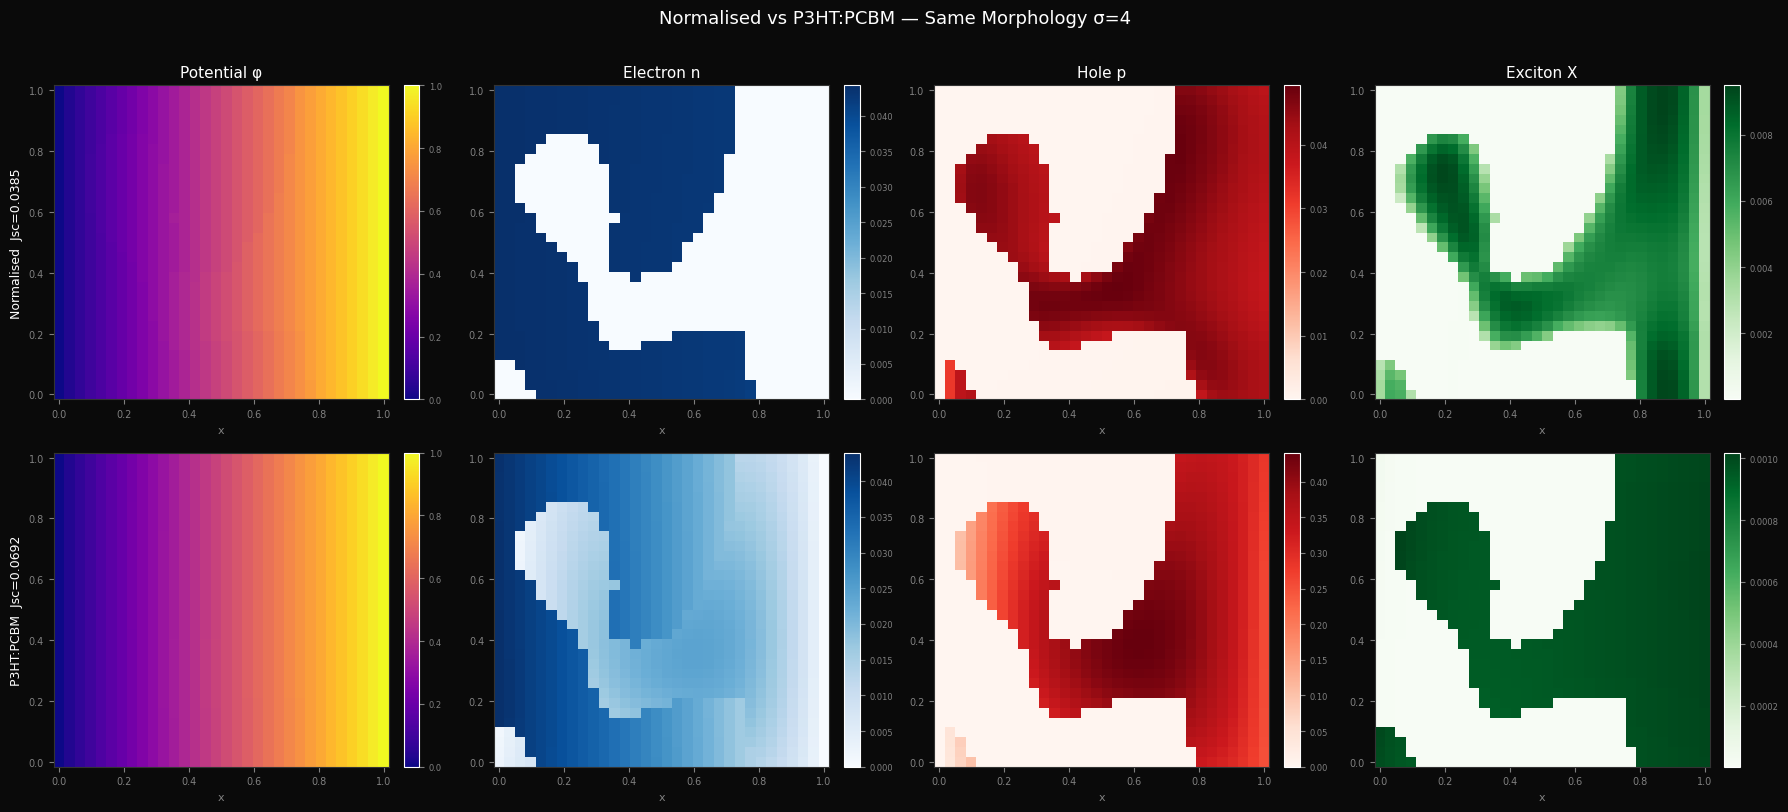

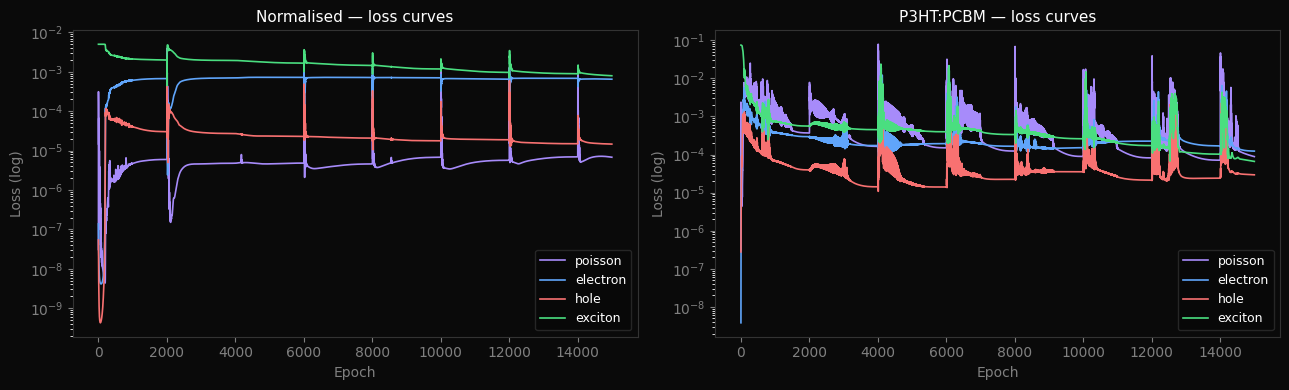

In [2]:
# ============================================
# CELL 1: IMPORTS
# ============================================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

# ============================================
# CELL 2: PHYSICAL CONSTANTS
# ============================================
q_SI  = 1.602e-19    # C
k_B   = 8.617e-5     # eV/K
eps_0 = 8.854e-12    # F/m

# ============================================
# CELL 3: PARAMETER CLASSES
# ============================================
class NormalisedParams:
    name        = "Normalised (dimensionless)"
    L0          = 1.0
    V0          = 1.0
    n0          = 1.0
    T           = 300
    q           = 1.0
    Vt          = 0.025
    eps         = 1.0
    mu_n        = 1.0
    mu_p        = 1.0
    mu_X        = 1.0
    k_rec       = 0.1
    k_diss      = 5.0
    G           = 0.1
    debye_ratio = 1.0

class P3HT_PCBM_Params:
    name = "P3HT:PCBM (physical)"
    T    = 300

    # Physical values
    L_phys    = 100e-9
    eps_r     = 3.5
    mu_n_phys = 1e-7
    mu_p_phys = 1e-8
    mu_X_phys = 1e-8
    k_rec_phys= 1e-18
    k_diss_phys=1e8
    G_phys    = 1e27
    n0        = 1e22

    # Reference scales
    L0  = L_phys
    V0  = k_B * T
    t0  = L0**2 / (mu_n_phys * V0)

    # Dimensionless parameters
    q           = 1.0
    Vt          = 1.0
    eps         = (eps_r * eps_0 * V0) / (q_SI * n0 * L0**2)
    mu_n        = 1.0
    mu_p        = mu_p_phys / mu_n_phys
    mu_X        = mu_X_phys / mu_n_phys
    k_rec       = k_rec_phys * n0 * t0
    k_diss      = k_diss_phys * t0
    G           = G_phys * t0 / n0
    debye_ratio = (q_SI * n0 * L0**2) / (eps_r * eps_0 * V0)

    # Physical current scale for converting Jsc back
    J0 = q_SI * n0 * mu_n_phys * V0 / L0   # A/m²

class CustomParams:
    """Fill in when real parameters arrive."""
    name = "Custom"

    # ---- FILL THESE IN ----
    L_phys    = None   # m
    T         = 300    # K
    eps_r     = None
    mu_n_phys = None   # m²/Vs
    mu_p_phys = None   # m²/Vs
    mu_X_phys = None   # m²/Vs
    k_rec_phys= None   # m³/s
    k_diss_phys=None   # s⁻¹
    G_phys    = None   # m⁻³s⁻¹
    n0        = None   # m⁻³
    # ---- END FILL IN ----

    @classmethod
    def compute_dimensionless(cls):
        assert cls.L_phys    is not None, "Fill in L_phys"
        assert cls.mu_n_phys is not None, "Fill in mu_n_phys"
        assert cls.n0        is not None, "Fill in n0"

        cls.L0  = cls.L_phys
        cls.V0  = k_B * cls.T
        cls.t0  = cls.L0**2 / (cls.mu_n_phys * cls.V0)

        cls.q           = 1.0
        cls.Vt          = 1.0
        cls.eps         = (cls.eps_r * eps_0 * cls.V0) / (q_SI * cls.n0 * cls.L0**2)
        cls.mu_n        = 1.0
        cls.mu_p        = cls.mu_p_phys  / cls.mu_n_phys
        cls.mu_X        = cls.mu_X_phys  / cls.mu_n_phys
        cls.k_rec       = cls.k_rec_phys  * cls.n0 * cls.t0
        cls.k_diss      = cls.k_diss_phys * cls.t0
        cls.G           = cls.G_phys * cls.t0 / cls.n0
        cls.debye_ratio = (q_SI * cls.n0 * cls.L0**2) / (cls.eps_r * eps_0 * cls.V0)
        cls.J0          = q_SI * cls.n0 * cls.mu_n_phys * cls.V0 / cls.L0

        sanity_check(cls)

def sanity_check(P):
    checks = {
        'Vt':     P.Vt,
        'eps':    P.eps,
        'mu_p':   P.mu_p,
        'mu_X':   P.mu_X,
        'k_rec':  P.k_rec,
        'k_diss': P.k_diss,
        'G':      P.G,
    }
    print(f"\nSanity check — {P.name}")
    print(f"  All should be in [1e-3, 1e3]:")
    all_ok = True
    for name, val in checks.items():
        ok     = 1e-3 <= abs(val) <= 1e3
        status = "✅" if ok else "⚠️  OUT OF RANGE"
        print(f"    {name:<10} = {val:.4e}  {status}")
        if not ok: all_ok = False
    if all_ok:
        print(f"  ✅ All parameters safe for training.")
    else:
        print(f"  ⚠️  Adjust n0 or L0 reference scales.")
    print(f"  Debye ratio = {P.debye_ratio:.2f}")
    return all_ok

# Run sanity checks
print("="*50)
sanity_check(NormalisedParams())
print()
sanity_check(P3HT_PCBM_Params())

# ============================================
# CELL 4: MORPHOLOGY
# ============================================
N_grid = 32

np.random.seed(42)
noise     = np.random.randn(N_grid, N_grid)
smoothed  = gaussian_filter(noise, sigma=4)
M_np      = (smoothed > np.percentile(smoothed, 50)).astype(float)
M_flat    = torch.tensor(
    M_np.flatten(), dtype=torch.float32
).reshape(-1, 1).to(device)

def interface_fraction(M):
    h = np.abs(np.diff(M, axis=0)).sum()
    v = np.abs(np.diff(M, axis=1)).sum()
    return (h + v) / M.size

print(f"Morphology σ=4: donor={M_np.mean():.1%}  "
      f"interface={interface_fraction(M_np):.1%}")

# ============================================
# CELL 5: NETWORK
# ============================================
def make_net(hidden=128):
    net = nn.Sequential(
        nn.Linear(3, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, 1)
    )
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    return net

class PINN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.phi_net = make_net()
        self.n_net   = make_net()
        self.p_net   = make_net()
        self.X_net   = make_net()

    def forward(self, coords, M):
        inp = torch.cat([coords, M], dim=1)
        x   = coords[:, 0:1]
        phi = x  +  x * (1 - x) * self.phi_net(inp)
        n   = (1 - x) * torch.nn.functional.softplus(self.n_net(inp))
        p   = x       * torch.nn.functional.softplus(self.p_net(inp) + 1.0)
        X   =           torch.nn.functional.softplus(self.X_net(inp))
        return phi, n, p, X

# ============================================
# CELL 6: HELPERS
# ============================================
def grad(f, coords):
    return torch.autograd.grad(
        f, coords,
        grad_outputs=torch.ones_like(f),
        create_graph=True, retain_graph=True)[0]

def laplacian(f, coords):
    g   = grad(f, coords)
    gxx = grad(g[:, 0:1], coords)[:, 0:1]
    gyy = grad(g[:, 1:2], coords)[:, 1:2]
    return gxx + gyy

def divergence(Fx, Fy, coords):
    return (grad(Fx, coords)[:, 0:1] +
            grad(Fy, coords)[:, 1:2])

def fresh_coords():
    x_lin  = torch.linspace(0, 1, N_grid)
    y_lin  = torch.linspace(0, 1, N_grid)
    Xg, Yg = torch.meshgrid(x_lin, y_lin, indexing='ij')
    c = torch.stack([Xg, Yg], dim=-1).reshape(-1, 2).to(device)
    c.requires_grad_(True)
    return c

# ============================================
# CELL 7: COMPUTE ALL — takes P as argument
# ============================================
def compute_all(coords, M_flat, model, P):
    phi, n, p, X = model(coords, M_flat)

    grad_phi = grad(phi, coords)
    grad_n   = grad(n,   coords)
    grad_p   = grad(p,   coords)
    grad_X   = grad(X,   coords)
    lap_phi  = laplacian(phi, coords)
    lap_X    = laplacian(X,   coords)

    Jn_x = -P.q*n*P.mu_n*grad_phi[:,0:1] + P.q*P.Vt*P.mu_n*grad_n[:,0:1]
    Jn_y = -P.q*n*P.mu_n*grad_phi[:,1:2] + P.q*P.Vt*P.mu_n*grad_n[:,1:2]
    Jp_x = -P.q*p*P.mu_p*grad_phi[:,0:1] - P.q*P.Vt*P.mu_p*grad_p[:,0:1]
    Jp_y = -P.q*p*P.mu_p*grad_phi[:,1:2] - P.q*P.Vt*P.mu_p*grad_p[:,1:2]

    div_Jn    = divergence(Jn_x, Jn_y, coords)
    div_Jp    = divergence(Jp_x, Jp_y, coords)

    R         = P.k_rec  * n * p
    R_X       = P.k_rec  * X
    field_mag = torch.norm(grad_phi, dim=1, keepdim=True)
    D_term    = P.k_diss * X * field_mag
    G_field   = P.G * M_flat

    # Poisson — debye_ratio is the key physical change
    L_poisson  = torch.mean(
        (P.debye_ratio * lap_phi - P.q*(n - p))**2
    )
    L_electron = torch.mean((div_Jn   - R + D_term)**2)
    L_hole     = torch.mean((-div_Jp  - R + D_term)**2)
    L_exciton  = torch.mean(
        (P.Vt*P.mu_X*lap_X - D_term - R_X + G_field)**2
    )

    y_c    = coords[:, 1]
    y0     = y_c < (1.0/N_grid)
    y1     = y_c > (1.0 - 1.0/N_grid)
    L_xbc  = (torch.mean(grad_X[y0, 1:2]**2) +
               torch.mean(grad_X[y1, 1:2]**2))
    L_pbc  = (torch.mean(grad_phi[y0, 1:2]**2) +
               torch.mean(grad_phi[y1, 1:2]**2))
    L_nd   = torch.mean((n * M_flat)**2)
    L_pd   = torch.mean((p * (1 - M_flat))**2)
    L_cons = torch.var(Jn_x + Jp_x)

    return (L_poisson, L_electron, L_hole, L_exciton,
            L_xbc, L_pbc, L_nd, L_pd, L_cons, Jn_x, Jp_x)

# ============================================
# CELL 8: TRAINING FUNCTION
# ============================================
def train_model(M_flat, P, label=''):
    print(f"\n{'='*55}")
    print(f"Training: {label}  [{P.name}]")
    print(f"{'='*55}")

    model = PINN2D().to(device)

    # Phase 1
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    print("Phase 1: Poisson only")
    for epoch in range(3000):
        opt.zero_grad()
        c = fresh_coords()
        L_p, *_ = compute_all(c, M_flat, model, P)
        L_p.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if epoch % 1000 == 0:
            print(f"  {epoch:4d} | poisson={L_p.item():.6f}")

    # Phase 2
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)
    print("Phase 2: + electron + hole")
    for epoch in range(5000):
        opt.zero_grad()
        c = fresh_coords()
        L_p, L_e, L_h, *_ = compute_all(c, M_flat, model, P)
        loss = L_p + L_e + L_h
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if epoch % 1500 == 0:
            print(f"  {epoch:4d} | p={L_p.item():.5f} "
                  f"e={L_e.item():.5f} h={L_h.item():.5f}")

    # Phase 3
    opt = torch.optim.Adam(model.parameters(), lr=2e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=2000)
    history = {"poisson":[], "electron":[], "hole":[], "exciton":[]}
    print("Phase 3: Full system")

    for epoch in range(15000):
        opt.zero_grad()
        c = fresh_coords()
        (L_p, L_e, L_h, L_x, L_xbc,
         L_pbc, L_nd, L_pd,
         L_cons, Jn_x, Jp_x) = compute_all(c, M_flat, model, P)

        loss = (  1.0*L_p  + 1.0*L_e  + 5.0*L_h
                + 1.0*L_x  + 5.0*L_xbc + 5.0*L_pbc
                + 10.0*L_nd + 10.0*L_pd + 50.0*L_cons)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sch.step()

        history["poisson"].append(L_p.item())
        history["electron"].append(L_e.item())
        history["hole"].append(L_h.item())
        history["exciton"].append(L_x.item())

        if epoch % 5000 == 0:
            print(f"  {epoch:5d} | p={L_p.item():.5f} "
                  f"e={L_e.item():.5f} h={L_h.item():.5f} "
                  f"x={L_x.item():.5f} cons={L_cons.item():.2e}")

    # Evaluate
    model.eval()
    c_eval = fresh_coords()
    phi_v, n_v, p_v, X_v = model(c_eval, M_flat)
    gp  = grad(phi_v, c_eval)
    gn  = grad(n_v,   c_eval)
    gpp = grad(p_v,   c_eval)
    Jn_x_v = -P.q*n_v*P.mu_n*gp[:,0:1] + P.q*P.Vt*P.mu_n*gn[:,0:1]
    Jp_x_v = -P.q*p_v*P.mu_p*gp[:,0:1] - P.q*P.Vt*P.mu_p*gpp[:,0:1]
    Jtot   =  Jn_x_v + Jp_x_v

    Jsc   = -float(Jtot.reshape(N_grid,N_grid)[-1,:].mean().detach())
    J_var = float(torch.var(Jtot).detach())
    Jsc   = max(Jsc, 0.0)

    print(f"\nResults:")
    print(f"  Jsc (normalised) = {Jsc:.6f}")
    if hasattr(P, 'J0'):
        Jsc_Am2  = Jsc * P.J0
        print(f"  Jsc (A/m²)       = {Jsc_Am2:.4e}")
        print(f"  Jsc (mA/cm²)     = {Jsc_Am2/10:.4f}")
    print(f"  J_var            = {J_var:.2e}")

    return model, Jsc, J_var, history

# ============================================
# CELL 9: RUN BOTH
# ============================================
P_norm = NormalisedParams()
P_phys = P3HT_PCBM_Params()

model_norm, Jsc_norm, Jvar_norm, hist_norm = train_model(
    M_flat, P_norm, label='Normalised')

model_phys, Jsc_phys, Jvar_phys, hist_phys = train_model(
    M_flat, P_phys, label='P3HT:PCBM')

# ============================================
# CELL 10: COMPARISON TABLE
# ============================================
print(f"\n{'='*55}")
print(f"Normalised vs P3HT:PCBM — σ=4 morphology")
print(f"{'='*55}")
print(f"{'Metric':<22} {'Normalised':>14} {'P3HT:PCBM':>14}")
print(f"{'-'*55}")
print(f"{'Jsc (normalised)':<22} {Jsc_norm:>14.4f} {Jsc_phys:>14.4f}")
if hasattr(P_phys, 'J0'):
    print(f"{'Jsc (mA/cm²)':<22} {'N/A':>14} {Jsc_phys*P_phys.J0/10:>14.4f}")
print(f"{'J_var':<22} {Jvar_norm:>14.2e} {Jvar_phys:>14.2e}")
print(f"{'debye_ratio':<22} {P_norm.debye_ratio:>14.2f} {P_phys.debye_ratio:>14.2f}")
print(f"{'mu_p':<22} {P_norm.mu_p:>14.3f} {P_phys.mu_p:>14.3f}")
print(f"{'k_diss':<22} {P_norm.k_diss:>14.3f} {P_phys.k_diss:>14.3f}")
print(f"{'k_rec':<22} {P_norm.k_rec:>14.3f} {P_phys.k_rec:>14.3f}")
print(f"{'='*55}")

# ============================================
# CELL 11: VISUALIZATION
# ============================================
BG  = '#0a0a0a'
plt.style.use('dark_background')
x_ax = np.linspace(0, 1, N_grid)
y_ax = np.linspace(0, 1, N_grid)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor(BG)

for row, (mdl, P, row_label, Jsc) in enumerate([
    (model_norm, P_norm,
     f'Normalised  Jsc={Jsc_norm:.4f}', Jsc_norm),
    (model_phys, P_phys,
     f'P3HT:PCBM  Jsc={Jsc_phys:.4f}', Jsc_phys),
]):
    mdl.eval()
    c_vis = fresh_coords()
    phi_v, n_v, p_v, X_v = mdl(c_vis, M_flat)

    fields_vis = [
        (phi_v.detach().cpu().numpy().reshape(N_grid,N_grid),
         'Potential φ', 'plasma'),
        (n_v.detach().cpu().numpy().reshape(N_grid,N_grid),
         'Electron n',  'Blues'),
        (p_v.detach().cpu().numpy().reshape(N_grid,N_grid),
         'Hole p',      'Reds'),
        (X_v.detach().cpu().numpy().reshape(N_grid,N_grid),
         'Exciton X',   'Greens'),
    ]

    for col, (field, title, cmap) in enumerate(fields_vis):
        ax = axes[row, col]
        ax.set_facecolor(BG)
        im = ax.pcolormesh(x_ax, y_ax, field.T,
                           cmap=cmap, shading='auto')
        plt.colorbar(im, ax=ax, fraction=0.046,
                     pad=0.04).ax.tick_params(
                     colors='gray', labelsize=6)
        if row == 0:
            ax.set_title(title, color='white', fontsize=11)
        if col == 0:
            ax.set_ylabel(row_label, color='white', fontsize=9)
        ax.set_xlabel('x', color='gray', fontsize=8)
        ax.tick_params(colors='gray', labelsize=7)
        for s in ax.spines.values():
            s.set_edgecolor('#333333')

fig.suptitle(
    'Normalised vs P3HT:PCBM — Same Morphology σ=4',
    color='white', fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('normalised_vs_p3ht.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

# Loss curves
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4))
fig2.patch.set_facecolor(BG)

for ax, (hist, label, color_set) in zip(axes2, [
    (hist_norm, 'Normalised',
     ['#a78bfa','#60a5fa','#f87171','#4ade80']),
    (hist_phys, 'P3HT:PCBM',
     ['#a78bfa','#60a5fa','#f87171','#4ade80']),
]):
    ax.set_facecolor(BG)
    for key, color in zip(
            ["poisson","electron","hole","exciton"],
            color_set):
        ax.semilogy(hist[key], linewidth=1.2,
                    color=color, label=key)
    ax.set_title(f'{label} — loss curves',
                 color='white', fontsize=11)
    ax.set_xlabel('Epoch', color='gray')
    ax.set_ylabel('Loss (log)', color='gray')
    ax.legend(fontsize=9, framealpha=0.15,
              labelcolor='white')
    ax.tick_params(colors='gray')
    for s in ax.spines.values():
        s.set_edgecolor('#333333')

plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()